# 03 CycleGAN Training

This notebook trains CycleGAN directly from notebook cells and saves the same artifacts into `outputs/`.


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "i2i").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current notebook directory.")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

print(f"Repo root: {REPO_ROOT}")
print(f"Working directory: {Path.cwd()}")


Repo root: /home/arderd/gan-lab-task-2
Working directory: /home/arderd/gan-lab-task-2


In [2]:
%pip install -r requirements.txt


Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import shutil
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image as PILImage
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from i2i.data import PairedImageDataset, UnpairedImageDataset
from i2i.models import NLayerDiscriminator, ResnetGenerator
from i2i.train_utils import (
    ReplayBuffer,
    append_jsonl,
    autocast_context,
    configure_runtime_for_device,
    compute_psnr_batch,
    count_parameters,
    ensure_dir,
    linear_decay_multiplier,
    move_modules_to_device,
    resolve_device,
    save_checkpoint,
    save_cyclegan_batch,
    set_seed,
)

def is_improved(metric_value: float, best_value: float, mode: str, min_delta: float) -> bool:
    if mode == "min":
        return metric_value < (best_value - min_delta)
    return metric_value > (best_value + min_delta)

@torch.no_grad()
def validate_cyclegan(
    g_ab: ResnetGenerator,
    g_ba: ResnetGenerator,
    loader: DataLoader,
    device: torch.device,
    use_channels_last: bool = False,
    max_batches: int | None = None,
    use_amp: bool = False,
) -> tuple[dict[str, float], tuple[torch.Tensor, ...] | None]:
    g_ab.eval()
    g_ba.eval()
    total_l1_ab = 0.0
    total_l1_ba = 0.0
    total_psnr_ab = 0.0
    total_psnr_ba = 0.0
    total_items = 0
    sample_bundle = None

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        real_a = batch["A"].to(device, non_blocking=(device.type == "cuda"))
        real_b = batch["B"].to(device, non_blocking=(device.type == "cuda"))
        if use_channels_last:
            real_a = real_a.contiguous(memory_format=torch.channels_last)
            real_b = real_b.contiguous(memory_format=torch.channels_last)
        with autocast_context(device, enabled=use_amp):
            fake_b = g_ab(real_a)
            fake_a = g_ba(real_b)
            rec_a = g_ba(fake_b)
            rec_b = g_ab(fake_a)

        if sample_bundle is None:
            sample_bundle = (
                real_a.detach().cpu(),
                fake_b.detach().cpu(),
                rec_a.detach().cpu(),
                real_b.detach().cpu(),
                fake_a.detach().cpu(),
                rec_b.detach().cpu(),
            )

        batch_size = real_a.size(0)
        total_items += batch_size
        total_l1_ab += float(nn.functional.l1_loss(fake_b, real_b, reduction="mean").item()) * batch_size
        total_l1_ba += float(nn.functional.l1_loss(fake_a, real_a, reduction="mean").item()) * batch_size
        total_psnr_ab += compute_psnr_batch(fake_b, real_b) * batch_size
        total_psnr_ba += compute_psnr_batch(fake_a, real_a) * batch_size

    if total_items == 0:
        return {
            "val_l1_ab": 0.0,
            "val_l1_ba": 0.0,
            "val_psnr_ab": 0.0,
            "val_psnr_ba": 0.0,
        }, sample_bundle

    return {
        "val_l1_ab": total_l1_ab / total_items,
        "val_l1_ba": total_l1_ba / total_items,
        "val_psnr_ab": total_psnr_ab / total_items,
        "val_psnr_ba": total_psnr_ba / total_items,
    }, sample_bundle

def train_cyclegan(
    *,
    data_root: Path,
    domain_a: str,
    domain_b: str,
    save_dir: Path,
    image_size: int,
    epochs: int,
    batch_size: int,
    num_workers: int,
    lr: float,
    beta1: float,
    beta2: float,
    lambda_cycle: float,
    lambda_identity: float,
    decay_start_epoch: int,
    max_val_batches: int | None,
    early_stopping_patience: int,
    early_stopping_metric: str,
    early_stopping_mode: str,
    early_stopping_min_delta: float,
    sample_every: int,
    checkpoint_every: int,
    num_sample_items: int,
    seed: int,
    device_arg: str,
    channels_last: bool = False,
    use_amp: bool | None = None,
    reset_run: bool = False,
) -> dict[str, Any]:
    set_seed(seed)

    if epochs <= 0:
        raise ValueError("epochs must be > 0")
    if not (0 < decay_start_epoch <= epochs):
        raise ValueError("decay_start_epoch must be in [1, epochs]")
    if early_stopping_patience < 0:
        raise ValueError("early_stopping_patience must be >= 0")
    if early_stopping_min_delta < 0:
        raise ValueError("early_stopping_min_delta must be >= 0")

    if reset_run and save_dir.exists():
        shutil.rmtree(save_dir)

    train_dataset = UnpairedImageDataset(
        root=data_root,
        split="train",
        domain_a=domain_a,
        domain_b=domain_b,
        image_size=image_size,
        hflip=True,
        random_pair=True,
    )
    val_dataset = PairedImageDataset(
        root=data_root,
        split="val",
        in_domain=domain_a,
        out_domain=domain_b,
        image_size=image_size,
        hflip=False,
    )

    device = resolve_device(device_arg)
    configure_runtime_for_device(device)
    modules, device, used_cpu_fallback = move_modules_to_device(
        {
            "g_ab": ResnetGenerator(in_channels=3, out_channels=3, n_blocks=9),
            "g_ba": ResnetGenerator(in_channels=3, out_channels=3, n_blocks=9),
            "d_a": NLayerDiscriminator(in_channels=3),
            "d_b": NLayerDiscriminator(in_channels=3),
        },
        device,
        allow_cpu_fallback=(device_arg.strip().lower() == "auto"),
    )
    g_ab = modules["g_ab"]
    g_ba = modules["g_ba"]
    d_a = modules["d_a"]
    d_b = modules["d_b"]
    if used_cpu_fallback:
        configure_runtime_for_device(device)
        print("CUDA was out of memory during model initialization. Falling back to CPU because DEVICE='auto'.")

    use_amp = (device.type == "cuda") if use_amp is None else bool(use_amp and device.type == "cuda")
    use_channels_last = channels_last and device.type == "cuda"
    if channels_last and device.type != "cuda":
        print(f"Note: channels_last is only enabled on CUDA. Ignoring it for device={device.type}.")
    print(
        f"Running on device={device}"
        f"{' with channels_last' if use_channels_last else ''} "
        f"{'with AMP ' if use_amp else ''}"
        f"(num_workers={num_workers})"
    )

    loader_kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": (device.type == "cuda"),
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 2

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)

    if use_channels_last:
        g_ab = g_ab.to(memory_format=torch.channels_last)
        g_ba = g_ba.to(memory_format=torch.channels_last)
        d_a = d_a.to(memory_format=torch.channels_last)
        d_b = d_b.to(memory_format=torch.channels_last)

    criterion_gan = nn.MSELoss()
    criterion_cycle = nn.L1Loss()
    criterion_identity = nn.L1Loss()

    optimizer_g = torch.optim.Adam(
        list(g_ab.parameters()) + list(g_ba.parameters()),
        lr=lr,
        betas=(beta1, beta2),
    )
    optimizer_d_a = torch.optim.Adam(d_a.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_d_b = torch.optim.Adam(d_b.parameters(), lr=lr, betas=(beta1, beta2))
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    lambda_fn = lambda epoch: linear_decay_multiplier(epoch, epochs, decay_start_epoch)
    scheduler_g = torch.optim.lr_scheduler.LambdaLR(optimizer_g, lr_lambda=lambda_fn)
    scheduler_d_a = torch.optim.lr_scheduler.LambdaLR(optimizer_d_a, lr_lambda=lambda_fn)
    scheduler_d_b = torch.optim.lr_scheduler.LambdaLR(optimizer_d_b, lr_lambda=lambda_fn)

    fake_a_buffer = ReplayBuffer(max_size=50)
    fake_b_buffer = ReplayBuffer(max_size=50)

    checkpoints_dir = ensure_dir(save_dir / "checkpoints")
    samples_dir = ensure_dir(save_dir / "samples")
    logs_dir = ensure_dir(save_dir / "logs")
    log_path = logs_dir / "train_log.jsonl"
    if log_path.exists() and reset_run:
        log_path.unlink()

    config = {
        "data_root": str(data_root),
        "domain_a": domain_a,
        "domain_b": domain_b,
        "image_size": image_size,
        "epochs": epochs,
        "batch_size": batch_size,
        "num_workers": num_workers,
        "lr": lr,
        "beta1": beta1,
        "beta2": beta2,
        "lambda_cycle": lambda_cycle,
        "lambda_identity": lambda_identity,
        "decay_start_epoch": decay_start_epoch,
        "max_val_batches": max_val_batches,
        "early_stopping_patience": early_stopping_patience,
        "early_stopping_metric": early_stopping_metric,
        "early_stopping_mode": early_stopping_mode,
        "early_stopping_min_delta": early_stopping_min_delta,
        "save_dir": str(save_dir),
        "sample_every": sample_every,
        "checkpoint_every": checkpoint_every,
        "num_sample_items": num_sample_items,
        "seed": seed,
        "device": str(device),
        "channels_last": use_channels_last,
        "use_amp": use_amp,
        "train_items": len(train_dataset),
        "val_pairs": len(val_dataset),
        "g_ab_params": count_parameters(g_ab),
        "g_ba_params": count_parameters(g_ba),
        "d_a_params": count_parameters(d_a),
        "d_b_params": count_parameters(d_b),
    }
    with (logs_dir / "config.json").open("w", encoding="utf-8") as config_file:
        json.dump(config, config_file, indent=2)

    best_val = float("-inf")
    early_enabled = early_stopping_patience > 0
    early_best = float("inf") if early_stopping_mode == "min" else float("-inf")
    early_best_epoch = 0
    bad_epochs = 0
    early_stopped = False
    early_stop_epoch = None
    total_train_start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        g_ab.train()
        g_ba.train()
        d_a.train()
        d_b.train()

        running = {
            "loss_g": 0.0,
            "loss_gan": 0.0,
            "loss_cycle": 0.0,
            "loss_identity": 0.0,
            "loss_d_a": 0.0,
            "loss_d_b": 0.0,
        }
        num_batches_seen = 0

        progress = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{epochs:03d}", leave=False)
        for batch in progress:
            real_a = batch["A"].to(device, non_blocking=(device.type == "cuda"))
            real_b = batch["B"].to(device, non_blocking=(device.type == "cuda"))
            if use_channels_last:
                real_a = real_a.contiguous(memory_format=torch.channels_last)
                real_b = real_b.contiguous(memory_format=torch.channels_last)

            with torch.no_grad():
                with autocast_context(device, enabled=use_amp):
                    valid_a = torch.ones_like(d_a(real_a))
                    valid_b = torch.ones_like(d_b(real_b))
            fake_label_a = torch.zeros_like(valid_a)
            fake_label_b = torch.zeros_like(valid_b)

            optimizer_g.zero_grad(set_to_none=True)
            with autocast_context(device, enabled=use_amp):
                id_a = g_ba(real_a)
                id_b = g_ab(real_b)
                loss_id_a = criterion_identity(id_a, real_a)
                loss_id_b = criterion_identity(id_b, real_b)
                loss_identity = (loss_id_a + loss_id_b) * lambda_cycle * lambda_identity

                fake_b = g_ab(real_a)
                fake_a = g_ba(real_b)
                loss_gan_ab = criterion_gan(d_b(fake_b), valid_b)
                loss_gan_ba = criterion_gan(d_a(fake_a), valid_a)
                loss_gan = loss_gan_ab + loss_gan_ba

                rec_a = g_ba(fake_b)
                rec_b = g_ab(fake_a)
                loss_cycle_a = criterion_cycle(rec_a, real_a)
                loss_cycle_b = criterion_cycle(rec_b, real_b)
                loss_cycle = (loss_cycle_a + loss_cycle_b) * lambda_cycle

                loss_g = loss_gan + loss_cycle + loss_identity
            scaler.scale(loss_g).backward()
            scaler.step(optimizer_g)

            optimizer_d_a.zero_grad(set_to_none=True)
            buffered_fake_a = fake_a_buffer.push_and_pop(fake_a.detach())
            with autocast_context(device, enabled=use_amp):
                loss_real_a = criterion_gan(d_a(real_a), valid_a)
                loss_fake_a = criterion_gan(d_a(buffered_fake_a), fake_label_a)
                loss_d_a = 0.5 * (loss_real_a + loss_fake_a)
            scaler.scale(loss_d_a).backward()
            scaler.step(optimizer_d_a)

            optimizer_d_b.zero_grad(set_to_none=True)
            buffered_fake_b = fake_b_buffer.push_and_pop(fake_b.detach())
            with autocast_context(device, enabled=use_amp):
                loss_real_b = criterion_gan(d_b(real_b), valid_b)
                loss_fake_b = criterion_gan(d_b(buffered_fake_b), fake_label_b)
                loss_d_b = 0.5 * (loss_real_b + loss_fake_b)
            scaler.scale(loss_d_b).backward()
            scaler.step(optimizer_d_b)
            scaler.update()

            running["loss_g"] += float(loss_g.item())
            running["loss_gan"] += float(loss_gan.item())
            running["loss_cycle"] += float(loss_cycle.item())
            running["loss_identity"] += float(loss_identity.item())
            running["loss_d_a"] += float(loss_d_a.item())
            running["loss_d_b"] += float(loss_d_b.item())
            num_batches_seen += 1
            progress.set_postfix(
                {
                    "G": f"{running['loss_g'] / num_batches_seen:.3f}",
                    "D_A": f"{running['loss_d_a'] / num_batches_seen:.3f}",
                    "D_B": f"{running['loss_d_b'] / num_batches_seen:.3f}",
                }
            )

        val_metrics, sample_bundle = validate_cyclegan(
            g_ab,
            g_ba,
            val_loader,
            device,
            use_channels_last=use_channels_last,
            max_batches=max_val_batches,
            use_amp=use_amp,
        )
        epoch_seconds = time.time() - epoch_start
        scheduler_g.step()
        scheduler_d_a.step()
        scheduler_d_b.step()

        metrics = {
            "epoch": epoch,
            "loss_g": running["loss_g"] / max(1, num_batches_seen),
            "loss_gan": running["loss_gan"] / max(1, num_batches_seen),
            "loss_cycle": running["loss_cycle"] / max(1, num_batches_seen),
            "loss_identity": running["loss_identity"] / max(1, num_batches_seen),
            "loss_d_a": running["loss_d_a"] / max(1, num_batches_seen),
            "loss_d_b": running["loss_d_b"] / max(1, num_batches_seen),
            "val_l1_ab": val_metrics["val_l1_ab"],
            "val_l1_ba": val_metrics["val_l1_ba"],
            "val_l1_sum": val_metrics["val_l1_ab"] + val_metrics["val_l1_ba"],
            "val_psnr_ab": val_metrics["val_psnr_ab"],
            "val_psnr_ba": val_metrics["val_psnr_ba"],
            "epoch_seconds": epoch_seconds,
            "lr": optimizer_g.param_groups[0]["lr"],
        }

        if early_enabled:
            if early_stopping_metric not in metrics:
                available = ", ".join(sorted(metrics.keys()))
                raise KeyError(
                    f"Early-stopping metric '{early_stopping_metric}' not found in metrics. Available metrics: {available}"
                )
            metric_value = float(metrics[early_stopping_metric])
            if is_improved(metric_value, early_best, early_stopping_mode, early_stopping_min_delta):
                early_best = metric_value
                early_best_epoch = epoch
                bad_epochs = 0
            else:
                bad_epochs += 1
            metrics["early_stop_metric"] = early_stopping_metric
            metrics["early_stop_metric_value"] = metric_value
            metrics["early_stop_best_value"] = early_best
            metrics["early_stop_best_epoch"] = early_best_epoch
            metrics["early_stop_bad_epochs"] = bad_epochs

        append_jsonl(log_path, metrics)

        if sample_bundle is not None and (epoch % sample_every == 0 or epoch == 1):
            save_cyclegan_batch(
                real_a=sample_bundle[0],
                fake_b=sample_bundle[1],
                rec_a=sample_bundle[2],
                real_b=sample_bundle[3],
                fake_a=sample_bundle[4],
                rec_b=sample_bundle[5],
                output_path=samples_dir / f"epoch_{epoch:03d}.png",
                max_items=num_sample_items,
            )

        checkpoint_payload = {
            "epoch": epoch,
            "g_ab_state": g_ab.state_dict(),
            "g_ba_state": g_ba.state_dict(),
            "d_a_state": d_a.state_dict(),
            "d_b_state": d_b.state_dict(),
            "optimizer_g_state": optimizer_g.state_dict(),
            "optimizer_d_a_state": optimizer_d_a.state_dict(),
            "optimizer_d_b_state": optimizer_d_b.state_dict(),
            "scheduler_g_state": scheduler_g.state_dict(),
            "scheduler_d_a_state": scheduler_d_a.state_dict(),
            "scheduler_d_b_state": scheduler_d_b.state_dict(),
            "metrics": metrics,
            "config": config,
        }

        if epoch % checkpoint_every == 0 or epoch == epochs:
            save_checkpoint(checkpoint_payload, checkpoints_dir / f"epoch_{epoch:03d}.pt")
        save_checkpoint(checkpoint_payload, checkpoints_dir / "latest.pt")

        score = val_metrics["val_psnr_ab"] + val_metrics["val_psnr_ba"]
        if score > best_val:
            best_val = score
            save_checkpoint(checkpoint_payload, checkpoints_dir / "best.pt")

        print(
            f"[CycleGAN] epoch={epoch:03d} "
            f"loss_g={metrics['loss_g']:.4f} d_a={metrics['loss_d_a']:.4f} d_b={metrics['loss_d_b']:.4f} "
            f"val_psnr_ab={metrics['val_psnr_ab']:.3f} val_psnr_ba={metrics['val_psnr_ba']:.3f} "
            f"time={metrics['epoch_seconds']:.1f}s"
        )

        if early_enabled and bad_epochs >= early_stopping_patience:
            early_stopped = True
            early_stop_epoch = epoch
            save_checkpoint(checkpoint_payload, checkpoints_dir / "early_stop.pt")
            print(
                f"Early stopping triggered at epoch {epoch:03d}. "
                f"best_{early_stopping_metric}={early_best:.4f} (epoch {early_best_epoch:03d})"
            )
            break

    total_seconds = time.time() - total_train_start
    summary = {
        "total_train_seconds": total_seconds,
        "best_val_score": best_val,
        "early_stopping_enabled": early_enabled,
        "early_stopped": early_stopped,
        "early_stop_epoch": early_stop_epoch,
        "early_stop_metric": early_stopping_metric,
        "early_stop_mode": early_stopping_mode,
        "early_stop_min_delta": early_stopping_min_delta,
        "early_stop_patience": early_stopping_patience,
        "early_stop_best_value": early_best if early_enabled else None,
        "early_stop_best_epoch": early_best_epoch if early_enabled else None,
    }
    with (logs_dir / "summary.json").open("w", encoding="utf-8") as summary_file:
        json.dump(summary, summary_file, indent=2)
    print(f"Training complete. Total time: {total_seconds / 60.0:.2f} min")
    return {
        "save_dir": save_dir,
        "checkpoints_dir": checkpoints_dir,
        "samples_dir": samples_dir,
        "logs_dir": logs_dir,
        "log_path": log_path,
        "summary": summary,
    }

def load_jsonl(path: Path) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []
    with path.open("r", encoding="utf-8") as log_file:
        for line in log_file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    if not rows:
        raise RuntimeError(f"No rows found in {path}")
    return rows

def infer_loss_keys(rows: list[dict[str, Any]]) -> list[str]:
    priority = [
        "loss_g",
        "loss_gan",
        "loss_cycle",
        "loss_identity",
        "loss_d_a",
        "loss_d_b",
        "val_l1_ab",
        "val_l1_ba",
        "val_l1_sum",
    ]
    available = set().union(*(row.keys() for row in rows))
    return [key for key in priority if key in available]

def infer_quality_keys(rows: list[dict[str, Any]]) -> list[str]:
    priority = ["val_psnr_ab", "val_psnr_ba"]
    available = set().union(*(row.keys() for row in rows))
    return [key for key in priority if key in available]

def get_series(rows: list[dict[str, Any]], key: str) -> tuple[list[int], list[float]]:
    x: list[int] = []
    y: list[float] = []
    for row in rows:
        epoch_value = row.get("epoch")
        metric_value = row.get(key)
        if isinstance(epoch_value, int) and isinstance(metric_value, (int, float)):
            x.append(epoch_value)
            y.append(float(metric_value))
    return x, y

def detect_plateau(
    rows: list[dict[str, Any]],
    metric: str,
    mode: str,
    patience: int,
    min_delta: float,
) -> dict[str, Any] | None:
    if patience <= 0:
        return None
    epochs, values = get_series(rows, metric)
    if not values:
        return None
    best_value = float("inf") if mode == "min" else float("-inf")
    best_epoch = epochs[0]
    bad_epochs = 0
    for epoch, value in zip(epochs, values):
        improved = value < (best_value - min_delta) if mode == "min" else value > (best_value + min_delta)
        if improved:
            best_value = value
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1
        if bad_epochs >= patience:
            return {
                "metric": metric,
                "mode": mode,
                "best_epoch": best_epoch,
                "best_value": best_value,
                "trigger_epoch": epoch,
                "patience": patience,
                "min_delta": min_delta,
            }
    return None

def build_training_plots(
    log_path: Path,
    title_prefix: str,
    plateau_metric: str = "val_l1_sum",
    plateau_mode: str = "min",
    plateau_patience: int = 10,
    plateau_min_delta: float = 0.0,
) -> dict[str, Any]:
    rows = load_jsonl(log_path)
    output_dir = (log_path.parent.parent / "plots") if log_path.parent.name == "logs" else (log_path.parent / "plots")
    output_dir.mkdir(parents=True, exist_ok=True)

    loss_keys = infer_loss_keys(rows)
    quality_keys = infer_quality_keys(rows)
    plateau_info = detect_plateau(rows, plateau_metric, plateau_mode, plateau_patience, plateau_min_delta)
    plateau_epoch = plateau_info["trigger_epoch"] if plateau_info else None

    def plot_keys(keys: list[str], title: str, y_label: str, output_path: Path) -> bool:
        if not keys:
            return False
        plotted = False
        plt.figure(figsize=(10, 6))
        for key in keys:
            x, y = get_series(rows, key)
            if not x:
                continue
            plotted = True
            plt.plot(x, y, marker="o", linewidth=1.5, markersize=3, label=key)
        if not plotted:
            plt.close()
            return False
        if plateau_epoch is not None:
            plt.axvline(plateau_epoch, color="red", linestyle="--", linewidth=1.2, label=f"plateau@{plateau_epoch}")
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel(y_label)
        plt.grid(True, linestyle="--", alpha=0.35)
        plt.legend()
        plt.tight_layout()
        plt.savefig(output_path, dpi=160)
        plt.show()
        return True

    loss_written = plot_keys(
        loss_keys,
        f"{title_prefix} - Loss vs Epoch",
        "Loss",
        output_dir / "loss_curves.png",
    )
    quality_written = plot_keys(
        quality_keys,
        f"{title_prefix} - Quality vs Epoch",
        "Quality Metric",
        output_dir / "quality_vs_epoch.png",
    )

    summary = {
        "log_path": str(log_path),
        "loss_keys": loss_keys,
        "quality_keys": quality_keys,
        "loss_plot_written": loss_written,
        "quality_plot_written": quality_written,
        "plateau": plateau_info,
    }
    with (output_dir / "plot_summary.json").open("w", encoding="utf-8") as summary_file:
        json.dump(summary, summary_file, indent=2)
    return summary

def show_latest_sample(samples_dir: Path, title: str) -> None:
    sample_paths = sorted(samples_dir.glob("epoch_*.png"))
    if not sample_paths:
        print(f"No sample images found in {samples_dir}")
        return
    latest = sample_paths[-1]
    with PILImage.open(latest) as image:
        plt.figure(figsize=(16, 6))
        plt.imshow(image)
        plt.title(f"{title} - {latest.name}")
        plt.axis("off")
        plt.show()


In [4]:
HOME = Path.home()
TMP_ROOT = HOME / "tmp"
DATA_ROOT = TMP_ROOT / "data" / "pix2pix-801010"
OUTPUT_ROOT = TMP_ROOT / "outputs"
DEVICE = "auto"
IMAGE_SIZE = 256
EPOCHS = 80
BATCH_SIZE = 16
NUM_WORKERS = 16
LR = 2e-4
BETA1 = 0.5
BETA2 = 0.999
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 0.5
DECAY_START_EPOCH = 40
MAX_VAL_BATCHES = 50
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_MIN_DELTA = 0.0005
SAMPLE_EVERY = 1
CHECKPOINT_EVERY = 10
NUM_SAMPLE_ITEMS = 4
SEED = 42
CHANNELS_LAST = torch.cuda.is_available()
RESET_RUN = False

{
    "data_root": str(DATA_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "epochs": EPOCHS,
    "device": DEVICE,
    "reset_run": RESET_RUN,
}


{'data_root': '/home/arderd/tmp/data/pix2pix-801010',
 'output_root': '/home/arderd/tmp/outputs',
 'epochs': 80,
 'device': 'auto',
 'reset_run': False}

## Train CycleGAN: satellite <-> map


In [5]:
cyclegan_run = train_cyclegan(
    data_root=DATA_ROOT,
    domain_a="sat",
    domain_b="map",
    save_dir=OUTPUT_ROOT / "cyclegan_sat_map",
    image_size=IMAGE_SIZE,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    lr=LR,
    beta1=BETA1,
    beta2=BETA2,
    lambda_cycle=LAMBDA_CYCLE,
    lambda_identity=LAMBDA_IDENTITY,
    decay_start_epoch=DECAY_START_EPOCH,
    max_val_batches=MAX_VAL_BATCHES,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    early_stopping_metric="val_l1_sum",
    early_stopping_mode="min",
    early_stopping_min_delta=EARLY_STOPPING_MIN_DELTA,
    sample_every=SAMPLE_EVERY,
    checkpoint_every=CHECKPOINT_EVERY,
    num_sample_items=NUM_SAMPLE_ITEMS,
    seed=SEED,
    device_arg=DEVICE,
    channels_last=CHANNELS_LAST,
    reset_run=RESET_RUN,
)
cyclegan_run["summary"]


Running on device=cuda:0 with channels_last with AMP (num_workers=16)


Epoch 001/080:   0%|          | 0/110 [00:00<?, ?it/s]

[CycleGAN] epoch=001 loss_g=5.5515 d_a=0.3310 d_b=0.2461 val_psnr_ab=21.500 val_psnr_ba=14.108 time=41.3s


Epoch 002/080:   0%|          | 0/110 [00:00<?, ?it/s]

[CycleGAN] epoch=002 loss_g=3.9831 d_a=0.2133 d_b=0.2048 val_psnr_ab=21.468 val_psnr_ba=14.666 time=39.2s


...

Epoch 025/080:   0%|          | 0/110 [00:00<?, ?it/s]

[CycleGAN] epoch=025 loss_g=2.4511 d_a=0.1554 d_b=0.2278 val_psnr_ab=23.080 val_psnr_ba=14.802 time=40.0s


Epoch 026/080:   0%|          | 0/110 [00:00<?, ?it/s]

[CycleGAN] epoch=026 loss_g=2.3394 d_a=0.1681 d_b=0.2159 val_psnr_ab=21.291 val_psnr_ba=15.367 time=40.4s
Early stopping triggered at epoch 026. best_val_l1_sum=0.3541 (epoch 014)
Training complete. Total time: 17.69 min


{'total_train_seconds': 1061.1037657260895,
 'best_val_score': 38.80707876649622,
 'early_stopping_enabled': True,
 'early_stopped': True,
 'early_stop_epoch': 26,
 'early_stop_metric': 'val_l1_sum',
 'early_stop_mode': 'min',
 'early_stop_min_delta': 0.0005,
 'early_stop_patience': 12,
 'early_stop_best_value': 0.3541293799468916,
 'early_stop_best_epoch': 14}

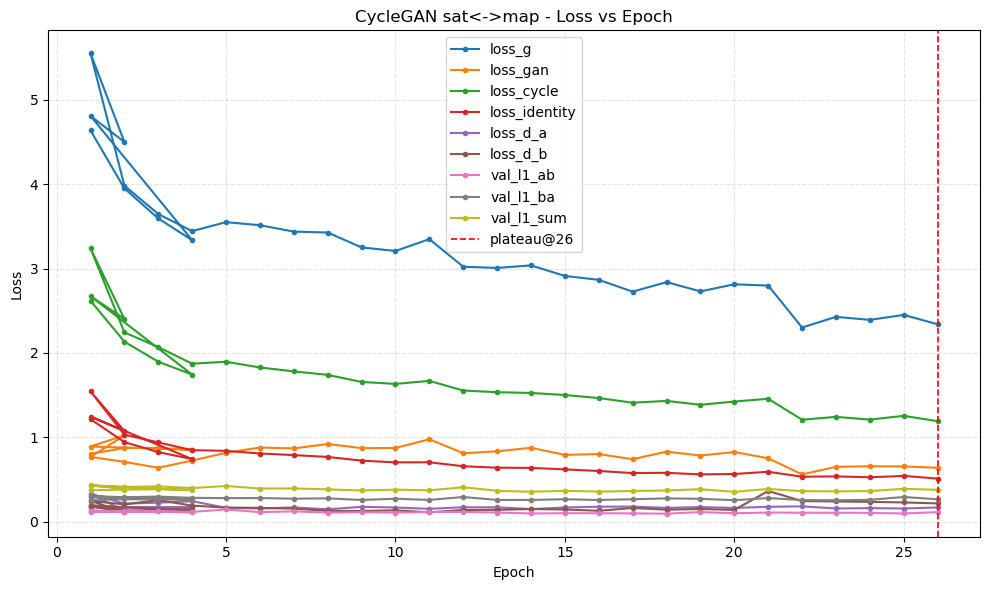

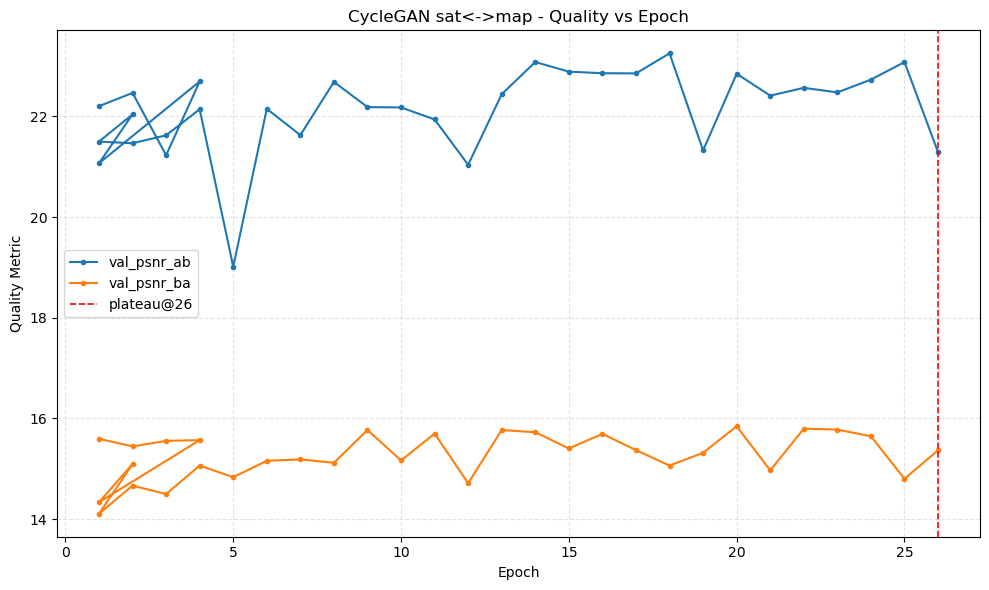

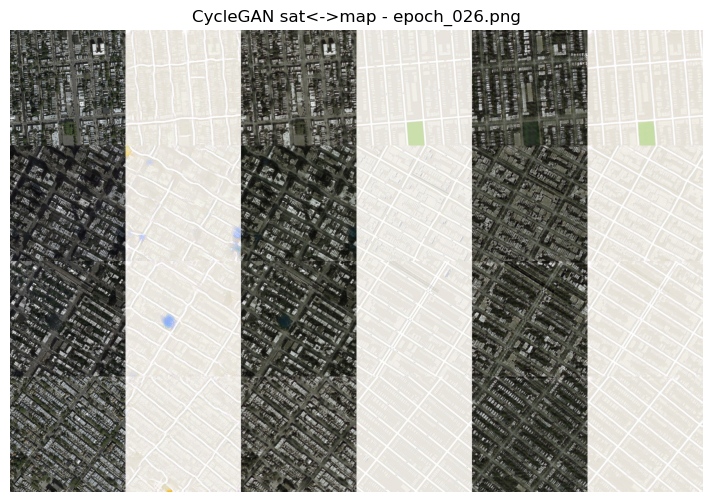

{'log_path': '/home/arderd/tmp/outputs/cyclegan_sat_map/logs/train_log.jsonl',
 'loss_keys': ['loss_g',
  'loss_gan',
  'loss_cycle',
  'loss_identity',
  'loss_d_a',
  'loss_d_b',
  'val_l1_ab',
  'val_l1_ba',
  'val_l1_sum'],
 'quality_keys': ['val_psnr_ab', 'val_psnr_ba'],
 'loss_plot_written': True,
 'quality_plot_written': True,
 'plateau': {'metric': 'val_l1_sum',
  'mode': 'min',
  'best_epoch': 14,
  'best_value': 0.3541293799468916,
  'trigger_epoch': 26,
  'patience': 12,
  'min_delta': 0.0005}}

In [6]:
cyclegan_plots = build_training_plots(
    cyclegan_run["log_path"],
    title_prefix="CycleGAN sat<->map",
    plateau_metric="val_l1_sum",
    plateau_mode="min",
    plateau_patience=EARLY_STOPPING_PATIENCE,
    plateau_min_delta=EARLY_STOPPING_MIN_DELTA,
)
show_latest_sample(cyclegan_run["samples_dir"], "CycleGAN sat<->map")
cyclegan_plots
